# 3.01 Peat Fire Extent Maps with Hex Grids (Alaska)

This notebook builds statewide hex-grid map products for peatland fire occurrence in Alaska using:
- Fire perimeters with `FIREYEAR`: `data/fire/fire_polygons.shp`
- Peat raster classes (`1` and `2` = peat): `data/peat/AlbersPeatMap.tif`
- Alaska boundary: `data/alaska_buffered.shp`

Requested map products (per hex cell):
1. Total peat-burned area (km²)
2. Percent of all burned area that was peat
3. Temporal density (`peat_fire_years / total_years_with_fire`)
4. Ratio `peat_burned_area / total_burned_area`
5. Cumulative time-since-first-peat-fire

Additional recommended maps are included at the end (first peat-fire year and peat burn pressure normalized by peat extent).

## Notes on temporal comparability

Fire-perimeter inclusion changed through time, so maps can be generated by scenario to reduce interpretation bias:
- `all_years` (historical archive; not directly comparable through time)
- `modern_1987plus` (more consistent perimeter inclusion)
- `current_2016plus` (highest perimeter completeness)

Recommended default for reporting statewide spatial patterns is `modern_1987plus`, with `current_2016plus` shown as a sensitivity check.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)

# --------------------------
# USER PARAMETERS
# --------------------------
FIRE_GDB = Path("data/fire/AlaskaFireHistory_Polygons.gdb")
FIRE_LAYER = "AK_fire_location_polygons_AKAlbersNAD83"
PEAT_RASTER = Path("data/peat/AlbersPeatMap.tif")
ALASKA_BOUNDARY = Path("data/alaska_buffered.shp")

# Set to 10 or 25 (or run both in separate notebook runs)
HEX_SIZE_KM = 25

# Temporal scenario for mapping
ANALYSIS_SCENARIO = "modern_1987plus"
SCENARIOS = {
    "all_years": (None, None),
    "modern_1987plus": (1987, None),
    "current_2016plus": (2016, None),
}

OUTDIR = Path("outputs/maps/hex_peat_fire_maps")
OUTDIR.mkdir(parents=True, exist_ok=True)

assert ANALYSIS_SCENARIO in SCENARIOS, f"Unknown scenario: {ANALYSIS_SCENARIO}"
assert HEX_SIZE_KM in (10, 25), "Set HEX_SIZE_KM to 10 or 25 for this workflow."

print(f"Scenario: {ANALYSIS_SCENARIO}")
print(f"Hex size: {HEX_SIZE_KM} km")
print(f"Output directory: {OUTDIR.resolve()}")

Scenario: modern_1987plus
Hex size: 25 km
Output directory: C:\Users\judith.ament\Documents\projects\alaska-peat\outputs\maps\hex_peat_fire_maps


In [7]:
# Load geospatial inputs and harmonize CRS
with rasterio.open(PEAT_RASTER) as src:
    peat_crs = src.crs
    transform = src.transform
    pixel_area_m2 = abs(transform.a * transform.e)

boundary = gpd.read_file(ALASKA_BOUNDARY)
fire_gdf = gpd.read_file(FIRE_GDB, layer=FIRE_LAYER)

if "FIREYEAR" not in fire_gdf.columns:
    raise ValueError("FIREYEAR attribute is missing from fire polygons.")

# Keep valid year + geometry
fires = fire_gdf.copy()
fires["FIREYEAR"] = pd.to_numeric(fires["FIREYEAR"], errors="coerce")
fires = fires.dropna(subset=["FIREYEAR", "geometry"]).copy()
fires["FIREYEAR"] = fires["FIREYEAR"].astype(int)
fires = fires[~fires.geometry.is_empty & fires.geometry.notna()].copy()

# Reproject everything to peat raster CRS (expected Alaska Albers)
if boundary.crs != peat_crs:
    boundary = boundary.to_crs(peat_crs)
if fires.crs != peat_crs:
    fires = fires.to_crs(peat_crs)

# Dissolve boundary to one geometry and repair invalid geometries before clipping
boundary_union = boundary.dissolve().reset_index(drop=True)

# Repair invalid geometries (prevents TopologyException on clip)
print("Validating and repairing geometries...")
boundary_union["geometry"] = boundary_union.geometry.apply(
    lambda geom: geom if geom.is_valid else geom.buffer(0)
)
fires["geometry"] = fires.geometry.apply(
    lambda geom: geom if geom.is_valid else geom.buffer(0)
)

# Clip fires to study area
fires = gpd.clip(fires[["FIREYEAR", "geometry"]], boundary_union)
fires = fires[~fires.geometry.is_empty & fires.geometry.notna()].copy()

print(f"Boundary CRS: {boundary_union.crs}")
print(f"Fire polygons in boundary: {len(fires):,}")
print(f"Year range: {fires['FIREYEAR'].min()}-{fires['FIREYEAR'].max()}")
print(f"Peat pixel area (m²): {pixel_area_m2}")

Validating and repairing geometries...
Boundary CRS: PROJCS["NAD83 / Alaska Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",50],PARAMETER["longitude_of_center",-154],PARAMETER["standard_parallel_1",55],PARAMETER["standard_parallel_2",65],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3338"]]
Fire polygons in boundary: 5,710
Year range: 1940-2024
Peat pixel area (m²): 400.0


In [8]:
def make_hexagon(cx, cy, r):
    angles = np.deg2rad(np.arange(0, 360, 60))
    coords = [(cx + r * np.cos(a), cy + r * np.sin(a)) for a in angles]
    return Polygon(coords)


def build_hex_grid(study_geom_gdf, hex_size_km):
    """Build a clipped regular hex grid over study area.
    hex_size_km is interpreted as approximate vertex-to-vertex diameter in km.
    """
    study_geom = study_geom_gdf.geometry.iloc[0]
    minx, miny, maxx, maxy = study_geom.bounds

    diameter_m = hex_size_km * 1000
    r = diameter_m / 2

    dx = 1.5 * r
    dy = np.sqrt(3) * r

    hexes = []
    col = 0
    x = minx - diameter_m
    while x <= maxx + diameter_m:
        y_offset = 0 if col % 2 == 0 else dy / 2
        y = miny - diameter_m + y_offset
        while y <= maxy + diameter_m:
            hexes.append(make_hexagon(x, y, r))
            y += dy
        x += dx
        col += 1

    grid = gpd.GeoDataFrame({"geometry": hexes}, crs=study_geom_gdf.crs)
    grid = gpd.overlay(grid, study_geom_gdf[["geometry"]], how="intersection")
    grid = grid[~grid.geometry.is_empty & grid.geometry.notna()].copy()
    grid = grid.reset_index(drop=True)
    grid["hex_id"] = [f"h_{i:06d}" for i in range(len(grid))]
    return grid


hex_grid = build_hex_grid(boundary_union, HEX_SIZE_KM)
print(f"Hex cells generated ({HEX_SIZE_KM} km): {len(hex_grid):,}")

Hex cells generated (25 km): 4,440


In [9]:
# Intersect fires with hex cells and compute total burned area per hex-year
intersections = gpd.overlay(
    fires[["FIREYEAR", "geometry"]],
    hex_grid[["hex_id", "geometry"]],
    how="intersection",
)
intersections = intersections[~intersections.geometry.is_empty & intersections.geometry.notna()].copy()
intersections["burned_area_km2"] = intersections.geometry.area / 1_000_000

# Dissolve geometry by hex-year to avoid repeated zonal calculations
geom_by_hex_year = intersections.groupby(["hex_id", "FIREYEAR"]) ["geometry"].apply(lambda g: g.union_all() if hasattr(g, 'union_all') else g.unary_union)
area_by_hex_year = intersections.groupby(["hex_id", "FIREYEAR"], as_index=False)["burned_area_km2"].sum()

cell_year = area_by_hex_year.copy()
cell_year["geometry"] = [geom_by_hex_year.loc[(r.hex_id, r.FIREYEAR)] for r in cell_year.itertuples(index=False)]
cell_year = gpd.GeoDataFrame(cell_year, geometry="geometry", crs=hex_grid.crs)

print(f"Hex-year records: {len(cell_year):,}")

Hex-year records: 8,330


In [10]:
# Compute peat-burned area in each hex-year intersection via raster zonal counts
zs = zonal_stats(
    cell_year.geometry,
    str(PEAT_RASTER),
    categorical=True,
    all_touched=False,
)

peat_pixel_counts = []
for d in zs:
    if d is None:
        peat_pixel_counts.append(0)
    else:
        peat_pixel_counts.append(int(d.get(1, 0)) + int(d.get(2, 0)))

cell_year["peat_burned_area_km2"] = (np.array(peat_pixel_counts) * pixel_area_m2) / 1_000_000
cell_year["peat_ratio"] = np.where(
    cell_year["burned_area_km2"] > 0,
    cell_year["peat_burned_area_km2"] / cell_year["burned_area_km2"],
    np.nan,
)

cell_year[["burned_area_km2", "peat_burned_area_km2", "peat_ratio"]].describe()

,burned_area_km2,peat_burned_area_km2,peat_ratio
count,8.330000e+03,8330.000000,8330.000000
mean,3.616740e+01,6.341718,0.180747
std,6.878897e+01,15.587377,0.219751
min,5.370942e-07,0.000000,0.000000
25%,6.744447e-01,0.012400,0.010077
50%,6.261163e+00,0.492000,0.091892
75%,3.540638e+01,4.513900,0.279519
max,5.499592e+02,231.561200,2.279111


In [11]:
def summarize_hex_metrics(cell_year_gdf, hex_grid_gdf, scenario_name, scenarios_dict):
    start_year, end_year = scenarios_dict[scenario_name]
    df = cell_year_gdf.copy()

    if start_year is not None:
        df = df[df["FIREYEAR"] >= start_year].copy()
    if end_year is not None:
        df = df[df["FIREYEAR"] <= end_year].copy()

    if df.empty:
        out = hex_grid_gdf.copy()
        for col in [
            "total_burned_area_km2",
            "total_peat_burned_area_km2",
            "peat_burn_pct_of_total",
            "peat_burn_ratio_of_total",
            "years_with_fire",
            "peat_fire_years",
            "peat_fire_frequency",
            "first_peat_fire_year",
            "cumulative_time_since_first_peat_fire",
        ]:
            out[col] = np.nan
        return out

    agg = (
        df.groupby("hex_id", as_index=False)
        .agg(
            total_burned_area_km2=("burned_area_km2", "sum"),
            total_peat_burned_area_km2=("peat_burned_area_km2", "sum"),
        )
    )

    yrs_fire = (
        df[df["burned_area_km2"] > 0]
        .groupby("hex_id")["FIREYEAR"]
        .nunique()
        .rename("years_with_fire")
    )

    peat_yrs = (
        df[df["peat_burned_area_km2"] > 0]
        .groupby("hex_id")["FIREYEAR"]
        .nunique()
        .rename("peat_fire_years")
    )

    first_peat = (
        df[df["peat_burned_area_km2"] > 0]
        .groupby("hex_id")["FIREYEAR"]
        .min()
        .rename("first_peat_fire_year")
    )

    out = hex_grid_gdf[["hex_id", "geometry"]].merge(agg, on="hex_id", how="left")
    out = out.merge(yrs_fire, on="hex_id", how="left")
    out = out.merge(peat_yrs, on="hex_id", how="left")
    out = out.merge(first_peat, on="hex_id", how="left")

    out["total_burned_area_km2"] = out["total_burned_area_km2"].fillna(0)
    out["total_peat_burned_area_km2"] = out["total_peat_burned_area_km2"].fillna(0)
    out["years_with_fire"] = out["years_with_fire"].fillna(0)
    out["peat_fire_years"] = out["peat_fire_years"].fillna(0)

    out["peat_burn_ratio_of_total"] = np.where(
        out["total_burned_area_km2"] > 0,
        out["total_peat_burned_area_km2"] / out["total_burned_area_km2"],
        np.nan,
    )
    out["peat_burn_pct_of_total"] = out["peat_burn_ratio_of_total"] * 100

    out["peat_fire_frequency"] = np.where(
        out["years_with_fire"] > 0,
        out["peat_fire_years"] / out["years_with_fire"],
        np.nan,
    )

    end_ref = int(df["FIREYEAR"].max())
    out["cumulative_time_since_first_peat_fire"] = np.where(
        out["first_peat_fire_year"].notna(),
        end_ref - out["first_peat_fire_year"] + 1,
        np.nan,
    )

    return gpd.GeoDataFrame(out, geometry="geometry", crs=hex_grid_gdf.crs)


hex_metrics = summarize_hex_metrics(cell_year, hex_grid, ANALYSIS_SCENARIO, SCENARIOS)

print(hex_metrics[[
    'total_burned_area_km2',
    'total_peat_burned_area_km2',
    'peat_burn_pct_of_total',
    'peat_fire_frequency'
]].describe())

       total_burned_area_km2  total_peat_burned_area_km2  \
count            4440.000000                 4440.000000   
mean               43.986345                    8.408635   
std               100.169682                   30.467276   
min                 0.000000                    0.000000   
25%                 0.000000                    0.000000   
50%                 0.000000                    0.000000   
75%                20.798425                    1.773000   
max              1890.749410                 1326.294800   

       peat_burn_pct_of_total  peat_fire_frequency  
count             1857.000000          1857.000000  
mean                16.604876             0.783052  
std                 17.360530             0.312636  
min                  0.000000             0.000000  
25%                  3.365307             0.666667  
50%                 10.975465             1.000000  
75%                 24.523864             1.000000  
max                110.178709      

In [ ]:
# Optional normalization metric: peat burn pressure = cumulative peat burned / peat extent
hex_peat_zs = zonal_stats(
    hex_grid.geometry,
    str(PEAT_RASTER),
    categorical=True,
    all_touched=False,
)

hex_peat_pixels = [
    (int(d.get(1, 0)) + int(d.get(2, 0))) if d is not None else 0
    for d in hex_peat_zs
]
hex_grid["peat_extent_km2"] = (np.array(hex_peat_pixels) * pixel_area_m2) / 1_000_000

hex_metrics = hex_metrics.merge(hex_grid[["hex_id", "peat_extent_km2"]], on="hex_id", how="left")

hex_metrics["peat_burn_pressure"] = np.where(
    hex_metrics["peat_extent_km2"] > 0,
    hex_metrics["total_peat_burned_area_km2"] / hex_metrics["peat_extent_km2"],
    np.nan,
)

hex_metrics[["peat_extent_km2", "peat_burn_pressure"]].describe()


,peat_extent_km2,peat_burn_pressure
count,4440.000000,4262.000000
mean,27.478997,0.147450
std,34.195236,0.311137
min,0.000000,0.000000
25%,4.002900,0.000000
50%,14.365000,0.000000
75%,37.825000,0.101761
max,263.896800,7.011616


In [2]:
# Reload saved metrics (useful after a kernel restart)
suffix = f"{HEX_SIZE_KM}km_{ANALYSIS_SCENARIO}"
hex_gpkg = OUTDIR / f"hex_metrics_{suffix}.gpkg"
hex_csv = OUTDIR / f"hex_metrics_{suffix}.csv"
cell_year_csv = OUTDIR / f"hex_year_metrics_{suffix}.csv"

if hex_gpkg.exists():
    hex_metrics = gpd.read_file(hex_gpkg)
    print(f"Loaded hex_metrics from {hex_gpkg}")
elif hex_csv.exists():
    raise FileNotFoundError(
        f"Found {hex_csv} but not {hex_gpkg}. "
        "Plotting requires geometry, so load the GeoPackage output."
    )
else:
    raise FileNotFoundError(
        f"Could not find saved metrics file: {hex_gpkg}. "
        "Run the save-outputs cell once to create it."
    )

# Optional: restore cell_year for downstream year-range logic in plotting cell
if "cell_year" not in globals() and cell_year_csv.exists():
    cell_year = pd.read_csv(cell_year_csv)
    print(f"Loaded cell_year from {cell_year_csv}")

Loaded hex_metrics from outputs\maps\hex_peat_fire_maps\hex_metrics_25km_modern_1987plus.gpkg
Loaded cell_year from outputs\maps\hex_peat_fire_maps\hex_year_metrics_25km_modern_1987plus.csv


Saved individual maps: outputs\maps\hex_peat_fire_maps\peat_fire_25km_modern_1987plus.png


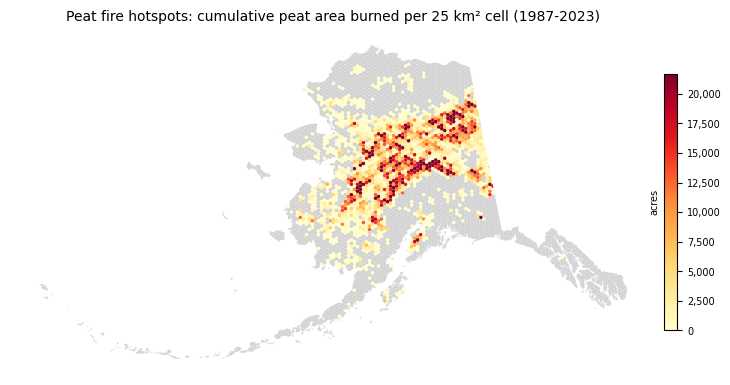

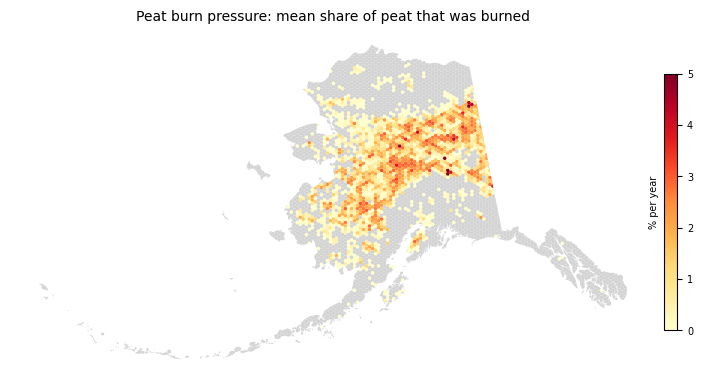

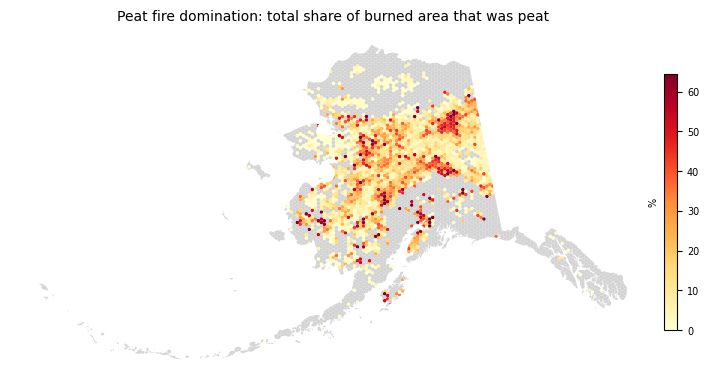

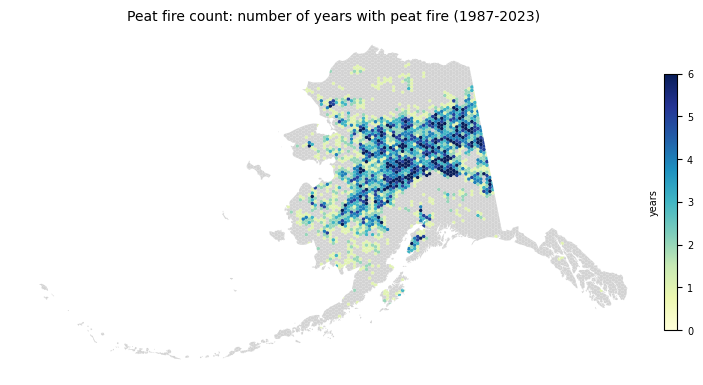

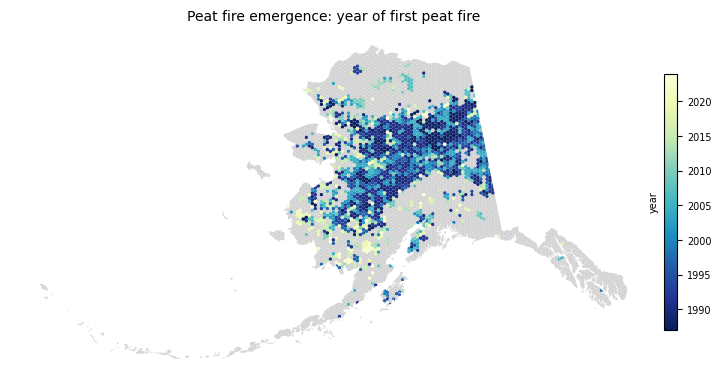

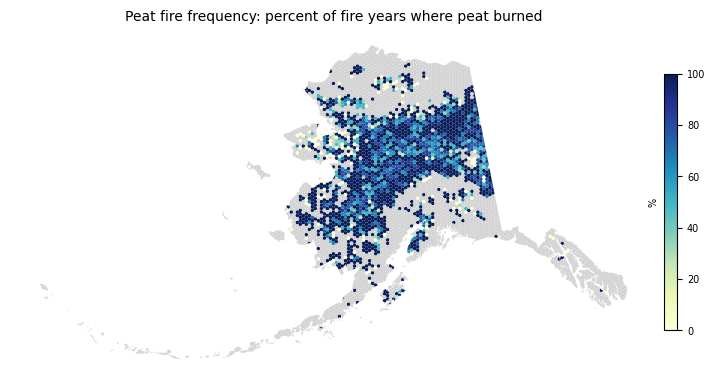

In [4]:
def _qmax(series, q=0.98):
    s = series.replace([np.inf, -np.inf], np.nan).dropna()
    if s.empty:
        return None
    return float(s.quantile(q))


def plot_hex_map(ax, gdf, col, title, cmap="viridis", vmin=None, vmax=None, units=None, suffix=None):
    data = gdf[["geometry", col]].copy()
    data.plot(
        column=col,
        ax=ax,
        cmap=cmap,
        linewidth=0.05,
        edgecolor="none",
        legend=True,
        vmin=vmin,
        vmax=vmax,
        legend_kwds={
            "shrink": 0.45,   # make legend/colorbar shorter
            "aspect": 20,     # keep it slim
            "pad": 0.01,      # closer to map
            "label": units if units else "",
        },
        missing_kwds={"color": "lightgray", "label": "No data"},
    )
    ax.set_title(title, fontsize=10)
    ax.set_axis_off()

    # reduce legend tick/label size and move label to left side
    if len(ax.figure.axes) > 1:
        cax = ax.figure.axes[-1]
        if cax is not ax:
            cax.tick_params(labelsize=7)
            cax.yaxis.set_label_position("left")
            cax.yaxis.label.set_size(7)
    
    # Store suffix mapping for later file naming
    if suffix is not None:
        _fig_suffix_mapping[ax.figure] = suffix


# Create 6 standalone figures (one map per figure)
_map_figs_axes = [plt.subplots(1, 1, figsize=(8, 6)) for _ in range(6)]
_map_figs = [fa[0] for fa in _map_figs_axes]
axes = np.array([fa[1] for fa in _map_figs_axes], dtype=object)

# Dictionary to track which figure corresponds to which file suffix
_fig_suffix_mapping = {}

# Patch pyplot calls used later in the cell so they apply to all 6 figures
_original_savefig = plt.savefig
_original_show = plt.show
_original_suptitle = plt.suptitle
_original_tight_layout = plt.tight_layout

def _save_all_hex_maps(path, *args, **kwargs):
    for fig_i in _map_figs:
        suffix = _fig_suffix_mapping.get(fig_i, "unknown")
        out = path.with_name(f"{path.stem}_{suffix}{path.suffix}")
        fig_i.savefig(out, *args, **kwargs)

def _show_all_hex_maps(*args, **kwargs):
    for fig_i in _map_figs:
        fig_i.show()

def _suptitle_all_hex_maps(*args, **kwargs):
    for fig_i in _map_figs:
        fig_i.suptitle(*args, **kwargs)

def _tight_layout_all_hex_maps(*args, **kwargs):
    for fig_i in _map_figs:
        fig_i.tight_layout(*args, **kwargs)

plt.savefig = _save_all_hex_maps
plt.show = _show_all_hex_maps
plt.suptitle = _suptitle_all_hex_maps
plt.tight_layout = _tight_layout_all_hex_maps
axes = axes.flatten()

# Convert km² to acres (1 km² = 247.105 acres)
hex_metrics["total_peat_burned_area_acres"] = hex_metrics["total_peat_burned_area_km2"] * 247.105

# Convert peat fire frequency to percent for mapping
hex_metrics["peat_fire_frequency_pct"] = hex_metrics["peat_fire_frequency"] * 100

# Calculate number of years for annualized metrics
start_year, end_year = SCENARIOS[ANALYSIS_SCENARIO]
max_year = int(cell_year["FIREYEAR"].max())
if start_year is None:
    start_year = int(cell_year["FIREYEAR"].min())
if end_year is None:
    end_year = max_year
num_years = end_year - start_year + 1

# Create annualized peat burn pressure for visualization
hex_metrics["peat_burn_pressure_annual"] = hex_metrics["peat_burn_pressure"] / num_years * 100

# Peat fire frequency as proportion of years in the archive
hex_metrics["peat_fire_frequency_archive"] = hex_metrics["peat_fire_years"] / num_years

# Display 0 values as NA for axes[0] and axes[1]
hex_metrics_masked_0 = hex_metrics.copy()
hex_metrics_masked_0.loc[hex_metrics_masked_0["total_peat_burned_area_acres"] == 0, "total_peat_burned_area_acres"] = np.nan
hex_metrics_masked_0.loc[
    hex_metrics_masked_0["peat_burn_pressure_annual"] == 0, "peat_burn_pressure_annual"
] = np.nan
hex_metrics_masked_0.loc[
    hex_metrics_masked_0["peat_fire_frequency_archive"] == 0, "peat_fire_frequency_archive"
] = np.nan
hex_metrics_masked_0.loc[
    hex_metrics_masked_0["peat_fire_years"] == 0, "peat_fire_years"
] = np.nan

plot_hex_map(
    axes[0],
    hex_metrics_masked_0,
    "total_peat_burned_area_acres",
    "Peat fire hotspots: cumulative peat area burned per 25 km² cell (1987-2023)",
    cmap="YlOrRd",
    # cmap="cividis",
    vmin=0,
    vmax=_qmax(hex_metrics["total_peat_burned_area_acres"]),
    units="acres",
    suffix="01_peat_fire_hotspots",
)

# Format colorbar tick labels with thousands separator
if len(axes[0].figure.axes) > 1:
    cax = axes[0].figure.axes[-1]
    if cax is not axes[0]:
        cax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plot_hex_map(
    axes[1],
    hex_metrics_masked_0,
    "peat_burn_pressure_annual",
    "Peat burn pressure: mean share of peat that was burned",
    cmap="YlOrRd",
    # cmap="cividis",
    vmin=0,
    vmax=5,
    # vmax=_qmax(hex_metrics["peat_burn_pressure_annual"]),
    units="% per year",
    suffix="02_peat_burn_pressure",
)

plot_hex_map(
    axes[2],
    hex_metrics,
    "peat_burn_pct_of_total",
    "Peat fire domination: total share of burned area that was peat",
    # cmap="PuRd",
    cmap="YlOrRd",
    # cmap="cividis",
    vmin=0,
    # vmax=100,
    vmax=_qmax(hex_metrics["peat_burn_pct_of_total"]),
    units="%",
    suffix="03_peat_dominated_fire",
)

plot_hex_map(
    axes[3],
    hex_metrics_masked_0,
    "peat_fire_years",
    "Peat fire count: number of years with peat fire (1987-2023)",
    cmap="YlGnBu",
    vmin=0,
    vmax=_qmax(hex_metrics["peat_fire_years"]),
    units="years",
    suffix="04_peat_fire_years",
)

# plot_hex_map(
#     axes[3],
#     hex_metrics_masked_0,
#     "peat_fire_frequency_archive",
#     "Peat fire occurrence: proportion of years with peat fire",
#     cmap="YlGnBu",
#     vmin=0,
#     vmax=_qmax(hex_metrics["peat_fire_frequency_archive"]),
#     units="proportion",
#     suffix="04_peat_fire_occurrence_frequency",
# )

plot_hex_map(
    axes[4],
    hex_metrics,
    "first_peat_fire_year",
    "Peat fire emergence: year of first peat fire",
    # cmap="PuRd",
    cmap="YlGnBu_r",
    # cmap="cividis_r",
    vmin=hex_metrics["first_peat_fire_year"].min(skipna=True),
    vmax=hex_metrics["first_peat_fire_year"].max(skipna=True),
    units="year",
    suffix="05_peat_fire_emergence",
)

plot_hex_map(
    axes[5],
    hex_metrics,
    "peat_fire_frequency_pct",
    "Peat fire frequency: percent of fire years where peat burned",
    cmap="YlGnBu",
    # cmap="PuRd",
    # cmap="cividis_r",
    vmin=0,
    vmax=_qmax(hex_metrics["peat_fire_frequency_pct"]),
    units="%",
    suffix="06_peat_fire_frequency",
)

plt.tight_layout()

map_png = OUTDIR / f"peat_fire_{HEX_SIZE_KM}km_{ANALYSIS_SCENARIO}.png"
plt.savefig(map_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved individual maps: {map_png}")

Saved combined panel figure: outputs\maps\hex_peat_fire_maps\peat_fire_panel_25km_modern_1987plus.png


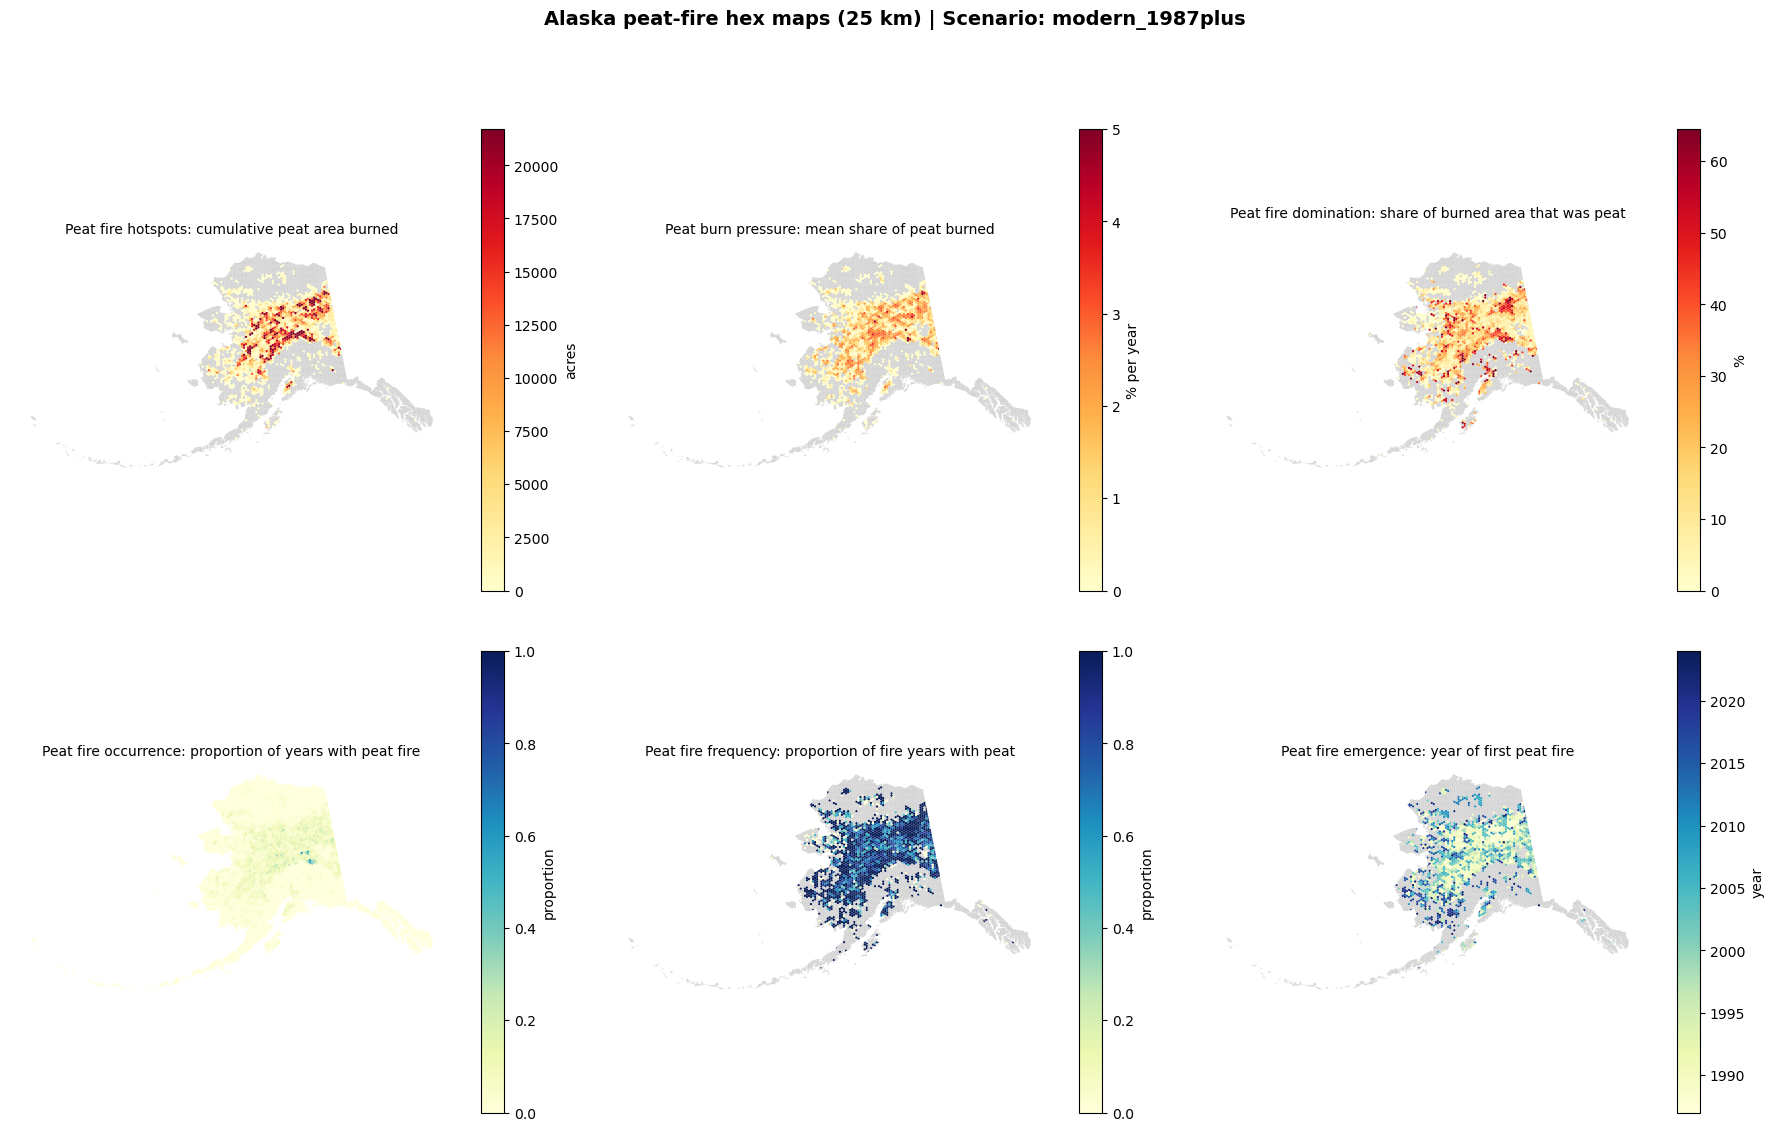

In [101]:
# Create combined panel with all 6 maps as subpanels
fig, panel_axes = plt.subplots(2, 3, figsize=(18, 12))
panel_axes = panel_axes.flatten()

# Map 1: Total peat burned area (acres)
hex_metrics_masked_0[["geometry", "total_peat_burned_area_acres"]].plot(
    column="total_peat_burned_area_acres",
    ax=panel_axes[0],
    cmap="YlOrRd",
    linewidth=0.05,
    edgecolor="none",
    legend=True,
    vmin=0,
    vmax=_qmax(hex_metrics["total_peat_burned_area_acres"]),
    legend_kwds={
        "shrink": 0.8,
        "aspect": 20,
        "label": "acres",
    },
    missing_kwds={"color": "lightgray", "label": "No data"},
)
panel_axes[0].set_title("Peat fire hotspots: cumulative peat area burned", fontsize=10)
panel_axes[0].set_axis_off()

# Map 2: Peat burn pressure annual
hex_metrics_masked_0[["geometry", "peat_burn_pressure_annual"]].plot(
    column="peat_burn_pressure_annual",
    ax=panel_axes[1],
    cmap="YlOrRd",
    linewidth=0.05,
    edgecolor="none",
    legend=True,
    vmin=0,
    vmax=5,
    legend_kwds={
        "shrink": 0.8,
        "aspect": 20,
        "label": "% per year",
    },
    missing_kwds={"color": "lightgray", "label": "No data"},
)
panel_axes[1].set_title("Peat burn pressure: mean share of peat burned", fontsize=10)
panel_axes[1].set_axis_off()

# Map 3: Peat burn pct of total
hex_metrics[["geometry", "peat_burn_pct_of_total"]].plot(
    column="peat_burn_pct_of_total",
    ax=panel_axes[2],
    cmap="YlOrRd",
    linewidth=0.05,
    edgecolor="none",
    legend=True,
    vmin=0,
    vmax=_qmax(hex_metrics["peat_burn_pct_of_total"]),
    legend_kwds={
        "shrink": 0.8,
        "aspect": 20,
        "label": "%",
    },
    missing_kwds={"color": "lightgray", "label": "No data"},
)
panel_axes[2].set_title("Peat fire domination: share of burned area that was peat", fontsize=10)
panel_axes[2].set_axis_off()

# Map 4: Peat fire occurrence frequency (archive)
hex_metrics[["geometry", "peat_fire_frequency_archive"]].plot(
    column="peat_fire_frequency_archive",
    ax=panel_axes[3],
    cmap="YlGnBu",
    linewidth=0.05,
    edgecolor="none",
    legend=True,
    vmin=0,
    vmax=1,
    legend_kwds={
        "shrink": 0.8,
        "aspect": 20,
        "label": "proportion",
    },
    missing_kwds={"color": "lightgray", "label": "No data"},
)
panel_axes[3].set_title("Peat fire occurrence: proportion of years with peat fire", fontsize=10)
panel_axes[3].set_axis_off()

# Map 5: Peat fire frequency (of fire years)
hex_metrics[["geometry", "peat_fire_frequency"]].plot(
    column="peat_fire_frequency",
    ax=panel_axes[4],
    cmap="YlGnBu",
    linewidth=0.05,
    edgecolor="none",
    legend=True,
    vmin=0,
    vmax=1,
    legend_kwds={
        "shrink": 0.8,
        "aspect": 20,
        "label": "proportion",
    },
    missing_kwds={"color": "lightgray", "label": "No data"},
)
panel_axes[4].set_title("Peat fire frequency: proportion of fire years with peat", fontsize=10)
panel_axes[4].set_axis_off()

# Map 6: First peat fire year
hex_metrics[["geometry", "first_peat_fire_year"]].plot(
    column="first_peat_fire_year",
    ax=panel_axes[5],
    cmap="YlGnBu",
    linewidth=0.05,
    edgecolor="none",
    legend=True,
    vmin=hex_metrics["first_peat_fire_year"].min(skipna=True),
    vmax=hex_metrics["first_peat_fire_year"].max(skipna=True),
    legend_kwds={
        "shrink": 0.8,
        "aspect": 20,
        "label": "year",
    },
    missing_kwds={"color": "lightgray", "label": "No data"},
)
panel_axes[5].set_title("Peat fire emergence: year of first peat fire", fontsize=10)
panel_axes[5].set_axis_off()

fig.suptitle(
    f"Alaska peat-fire hex maps ({HEX_SIZE_KM} km) | Scenario: {ANALYSIS_SCENARIO}",
    fontsize=14,
    fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.97])

panel_png = OUTDIR / f"peat_fire_panel_{HEX_SIZE_KM}km_{ANALYSIS_SCENARIO}.png"
fig.savefig(panel_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved combined panel figure: {panel_png}")

## How to Interpret the Hex-Map Outputs

These maps show complementary dimensions of where peat fire occurs and how important peat is within the broader fire regime.

1. **Total peat-burned area (km²)**  
   - **Depicts:** Absolute cumulative peat area burned per hex cell.  
   - **Why important:** Identifies where peat combustion is largest in total magnitude (potentially large carbon impact).  
   - **High vs low:** High values = major peat-fire hotspots in absolute area; low values = little cumulative peat burning.  
   - **Answers:** *Where has the most peat area burned overall?*

2. **% of all burned area that was peat**  
   - **Depicts:** Share of burned area in each cell that overlaps peat.  
   - **Why important:** Separates peat-dominated fire landscapes from places where fire occurs mostly on non-peat fuels.  
   - **High vs low:** High values = fire is disproportionately on peat; low values = fire mainly outside peat.  
   - **Answers:** *Where is fire behavior most peat-associated?*

3. **Peat fire frequency (`peat_fire_years / years_with_fire`)**  
   - **Depicts:** How often fire years in a cell involve peat burning.  
   - **Why important:** Highlights persistence/regularity of peat involvement through time, not just total area.  
   - **High vs low:** High values near 1 = peat burning occurs in most fire years; low values near 0 = peat is only occasional.  
   - **Answers:** *Where is peat burning a recurrent feature of the local fire regime?*

4. **Cumulative time since first peat fire (years)**  
   - **Depicts:** Number of years elapsed since first recorded peat fire (relative to scenario end year).  
   - **Why important:** Indicates temporal depth of peat-fire history in each location.  
   - **High vs low:** High values = long peat-fire history/early onset; low values = recent emergence of peat fire.  
   - **Answers:** *Where has peat fire been present the longest vs only recently?*

5. **Peat burn pressure (`cumulative peat burned / peat extent`)**  
   - **Depicts:** Cumulative peat area burned normalized by peat area available in each cell.  
   - **Why important:** Controls for uneven peat distribution, revealing relative pressure rather than absolute size effects.  
   - **High vs low:** High values = repeated/intense burning relative to local peat resource; low values = limited peat impact relative to availability.  
   - **Answers:** *Where is peat most heavily impacted after accounting for how much peat exists?*

### Practical reading notes

- Interpret **absolute** maps (#1) together with **relative** maps (#2/#4/#6) to avoid area-size bias.  
- Use #3 and #5 to distinguish long-term persistent peat-fire regions from newly active regions.  
- Keep temporal scenario (`all_years`, `1987+`, `2016+`) in mind when comparing patterns, since archive completeness changes through time.

In [34]:
# Save geospatial + tabular outputs
suffix = f"{HEX_SIZE_KM}km_{ANALYSIS_SCENARIO}"

hex_gpkg = OUTDIR / f"hex_metrics_{suffix}.gpkg"
hex_csv = OUTDIR / f"hex_metrics_{suffix}.csv"
cell_year_csv = OUTDIR / f"hex_year_metrics_{suffix}.csv"
scenario_csv = OUTDIR / f"scenario_summary_{HEX_SIZE_KM}km.csv"

hex_metrics.to_file(hex_gpkg, driver="GPKG")

hex_metrics.drop(columns="geometry").to_csv(hex_csv, index=False)
cell_year.drop(columns="geometry").to_csv(cell_year_csv, index=False)

# Small scenario comparison table for reporting context
rows = []
for sc_name in SCENARIOS:
    sc_hex = summarize_hex_metrics(cell_year, hex_grid, sc_name, SCENARIOS)
    rows.append({
        "scenario": sc_name,
        "hex_size_km": HEX_SIZE_KM,
        "sum_total_burned_km2": float(sc_hex["total_burned_area_km2"].sum()),
        "sum_total_peat_burned_km2": float(sc_hex["total_peat_burned_area_km2"].sum()),
        "mean_peat_burn_pct_of_total": float(sc_hex["peat_burn_pct_of_total"].mean(skipna=True)),
        "mean_peat_fire_frequency": float(sc_hex["peat_fire_frequency"].mean(skipna=True)),
    })

pd.DataFrame(rows).to_csv(scenario_csv, index=False)

print("Saved outputs:")
print(f"- {hex_gpkg}")
print(f"- {hex_csv}")
print(f"- {cell_year_csv}")
print(f"- {scenario_csv}")

Saved outputs:
- outputs\maps\hex_peat_fire_maps\hex_metrics_25km_modern_1987plus.gpkg
- outputs\maps\hex_peat_fire_maps\hex_metrics_25km_modern_1987plus.csv
- outputs\maps\hex_peat_fire_maps\hex_year_metrics_25km_modern_1987plus.csv
- outputs\maps\hex_peat_fire_maps\scenario_summary_25km.csv


## Suggested additional map types for report

Beyond the five requested maps, these are especially useful for statewide interpretation:

1. **First peat-fire year** (already included): shows spatial onset of peat fire occurrence.
2. **Peat burn pressure** (`cumulative peat burned / peat extent`): identifies cells with repeated peat burning relative to available peat area.
3. **Data-era facet maps** (same metric mapped for `all_years`, `1987+`, `2016+`): separates true spatial signal from changing archive completeness.
4. **Hotspot confidence layer**: map `years_with_fire` or `peat_fire_years` directly to indicate where ratios are based on sparse vs rich temporal samples.

## Summary of Methods and Map Interpretation

### **Methods Overview**

This analysis generates hex-grid map products to visualize peatland fire patterns across Alaska at a statewide scale. The workflow integrates three primary geospatial inputs:

1. **Fire perimeter polygons** with year attributes (`FIREYEAR`) from the Alaska Fire History geodatabase
2. **Peat distribution raster** (`AlbersPeatMap.tif`), where pixel values 1 and 2 indicate peat presence
3. **Alaska state boundary** for clipping and spatial extent control

**Key processing steps:**

- **Hexagonal tessellation**: A regular flat-top hexagon grid (user-specified 10 km or 25 km resolution) is constructed across Alaska and clipped to the state boundary. Each hex cell serves as a spatial reporting unit.
- **Fire-hex intersection**: Fire perimeters are spatially joined with hex cells to identify which fires occurred in which cells and when.
- **Peat burned area estimation**: Raster zonal statistics count peat pixels within fire perimeters for each hex-year combination, converting pixel counts to area (km²) using the raster's coordinate system transform.
- **Temporal aggregation**: For each hex cell, metrics are computed across all fire years (or within a user-specified temporal scenario: `all_years`, `modern_1987plus`, or `current_2016plus`).
- **Normalization metrics**: Several metrics normalize peat burning by total burned area, fire event frequency, or available peat extent to reveal relative patterns rather than absolute size effects.

**Temporal scenario rationale:**  
Historical fire perimeter archives have variable completeness through time. The `modern_1987plus` scenario (1987–present) reduces temporal bias by excluding early records with inconsistent coverage. The `current_2016plus` scenario provides a shorter but more complete window for sensitivity checks.

---

### **Map Products and Interpretation**

The script generates **7 map products**, each visualizing a different dimension of peat fire occurrence and impact:

---

#### **Map 1: Total Peat Burned Area (km²)**
- **Metric**: `total_peat_burned_area_km2`
- **Description**: Cumulative peat area burned per hex cell across all fire years in the analysis scenario.
- **What it shows**: Absolute magnitude of peat combustion—where the most peat has burned.
- **High values**: Major peat-fire hotspots with large cumulative carbon emissions potential.
- **Low values**: Minimal peat burning (either sparse peat, infrequent fire, or both).
- **Use case**: Prioritize cells for carbon impact assessment or retrospective emissions inventories.

---

#### **Map 2: Peat Burn % of Total Burned Area**
- **Metric**: `peat_burn_pct_of_total`
- **Description**: Percentage of all burned area in each cell that overlaps peat (0–100%).
- **What it shows**: How peat-dominated the fire regime is in each location.
- **High values**: Fire activity is concentrated on peatlands (peat-centric fire regime).
- **Low values**: Fire occurs mainly on non-peat fuels (mineral soils, upland vegetation).
- **Use case**: Distinguish peat-dominated fire landscapes from mixed or upland fire regimes.

---

#### **Map 3: Peat Fire Frequency**
- **Metric**: `peat_fire_frequency` = `peat_fire_years / years_with_fire`
- **Description**: Proportion of fire years in each cell that involved peat burning (0–1 scale).
- **What it shows**: How consistently peat is involved when fires occur in a given hex cell.
- **High values (near 1)**: Peat burns in most fire years—peat is a recurring fire fuel.
- **Low values (near 0)**: Peat burning is occasional or rare, even when fires are present.
- **Use case**: Identify locations where peat is a persistent vs. sporadic fire component.

---

#### **Map 4: Peat Burn Ratio of Total**
- **Metric**: `peat_burn_ratio_of_total` = `total_peat_burned_area_km2 / total_burned_area_km2`
- **Description**: Ratio of cumulative peat area burned to total area burned (0–1 scale; same as Map 2 but expressed as ratio rather than percentage).
- **What it shows**: Relative importance of peat in the cumulative burned area footprint.
- **High values**: Peat burning dominates the fire footprint.
- **Low values**: Non-peat fuels dominate.
- **Use case**: Similar to Map 2; useful when ratio format is preferred for modeling or statistical analysis.

---

#### **Map 5: Cumulative Time Since First Peat Fire (years)**
- **Metric**: `cumulative_time_since_first_peat_fire`
- **Description**: Number of years elapsed from the first recorded peat fire in each cell to the end of the analysis period.
- **What it shows**: Temporal depth of peat-fire history—where peat burning is long-standing vs. recently emerged.
- **High values**: Long-standing peat-fire presence (early onset).
- **Low values**: Recent emergence of peat fire activity.
- **Use case**: Identify legacy peat-fire regions vs. newly active regions (relevant for ecosystem recovery timescales and vulnerability trends).

---

#### **Map 6: Peat Burn Pressure**
- **Metric**: `peat_burn_pressure` = `total_peat_burned_area_km2 / peat_extent_km2`
- **Description**: Cumulative peat area burned normalized by total peat area available in each cell (0–1+ scale; values >1 indicate repeated burning of the same peat).
- **What it shows**: Relative intensity of peat burning after controlling for peat availability.
- **High values**: Repeated or intensive peat burning relative to local peat resources (high cumulative pressure).
- **Low values**: Limited peat impact despite peat presence.
- **Use case**: Prioritize cells with disproportionately high peat fire pressure, even if absolute burned area is moderate. Useful for identifying vulnerable peat patches under repeated fire stress.

---

#### **Map 7: Year of First Peat Fire**
- **Metric**: `first_peat_fire_year`
- **Description**: Calendar year when peat first burned in each hex cell (within the analysis scenario).
- **What it shows**: Spatial pattern of peat fire onset—where peat burning started early vs. late in the historical record.
- **Interpretation**: Color gradient from early years (e.g., 1950s–1980s) to recent years (e.g., 2000s–2020s) reveals the temporal spread of peat fire across the landscape.
- **Use case**: Identify whether peat fire emergence is spatially clustered by decade (e.g., a wave of new peat-fire regions in recent years vs. stable historical distribution). Useful for change-detection studies and climate-fire linkage hypotheses.

---

### **How to Read These Maps Together**

1. **Start with Maps 1 and 2** to distinguish large absolute impacts (Map 1) from peat-dominated fire regimes (Map 2). High values on both = major peat-fire hotspots.
2. **Add Map 3** to see whether peat burning is persistent (high frequency) or episodic (low frequency) in those hotspots.
3. **Use Map 5 and Map 7** together to understand temporal dimensions: long-standing peat-fire regions (Map 5 high values, Map 7 early years) vs. newly active regions (Map 5 low values, Map 7 recent years).
4. **Incorporate Map 6** to identify cells where peat is under disproportionate fire pressure relative to its availability—this is critical for conservation prioritization, as it reveals vulnerability even in cells with modest absolute burned area.
5. **Map 4** provides a ratio-based alternative to Map 2 for quantitative analysis workflows.

**Critical interpretation note:** The spatial patterns in these maps are influenced by historical fire perimeter archive completeness, which is lower before ~1987 and highest after ~2016. Always report which temporal scenario (`all_years`, `modern_1987plus`, or `current_2016plus`) was used, as this affects both the absolute values and the spatial patterns. For statewide reporting, the **`modern_1987plus`** scenario is recommended to balance temporal depth with data quality.